<a href="https://colab.research.google.com/github/CookOLo/MAT422/blob/main/HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.3 - Linear Regression

## 1.3.1 - QR Decomposition
QR Decomposition is $A = QR$ where:
- $A$ is a matrix
- $Q$ is a matrix that uses Gram-schmidt algorithm to obtain the orthonormal basis of $span(a_1,..., a_m)$ from a lineraly independent set of $span(a_1,..., a_m)$
- $R$ is a matrix that contains the coefficients of the linear combinations of $q_j$'s that produces $a_i$

In [24]:
# Imports
import numpy as np
from numpy.linalg import qr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [12]:
matrixBase = np.array([[1, 1], [-1, 3]]);

q, r = qr(matrixBase);

print("This is the Q of matrix [[1, 1], [-1, 3]]:\n", q);
print("\n");
print("This is the R of matrix [[1, 1], [-1, 3]]:\n", r);

## ^ dot product of q and r to confirm that this equals back into the original matrix
matrixBack = np.dot(q, r);
print("\n");
print("This is the dot product of the Q and R (should lead to the original matrix of [[1, 1], [-1, 3]]):\n", matrixBack);

This is the Q of matrix [[1, 1], [-1, 3]]:
 [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


This is the R of matrix [[1, 1], [-1, 3]]:
 [[-1.41421356  1.41421356]
 [ 0.          2.82842712]]


This is the dot product of the Q and R (should lead to the original matrix of [[1, 1], [-1, 3]]):
 [[ 1.  1.]
 [-1.  3.]]


## 1.3.2 Least-squares problems
- Let $A ∈ R^{n×m}$ be an $n x m$ matrix with lineraly independent columns
- Let $b ∈ R^n$ be a vector

^ This leads to the least-squares problem

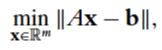

In [17]:
matrixA = np.array([[0, 1], [0, 2]]);
vecB = [-1, 2];

# does least square method through numpy
x = np.linalg.lstsq(matrixA, vecB, rcond=None)[0]
print("This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible:\n", x)

This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible:
 [0.  0.6]


**Theorem 1.3.1**: Normal Equations -- Solution to the least-squares problem must also satisfy:

$A^T Ax = A^T b$

In [21]:
# Confirming that previous solution to least square satifies to normal equations
matrixA = np.array([[0, 1], [0, 2]]);
vecB = [-1, 2];

matrixATransposed = np.transpose(matrixA);

MAT = np.dot(matrixATransposed, matrixA);
VEC = np.dot(matrixATransposed, vecB);

xNE = np.linalg.lstsq(MAT, VEC, rcond=None)[0]

print("This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible, proven through normal equations:\n", xNE)

This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible, proven through normal equations:
 [0.  0.6]


**Theorem 1.3.2**: Least squares via QR -- Solution to the least-squares problem must also satisfy:

$Rx^* = Q^T b$

In [22]:
# Confirming that previous solution to least square satifies to QR
matrixA = np.array([[0, 1], [0, 2]]);
vecB = [-1, 2];

q, r = qr(matrixA);

newA = r;
newB = np.dot(q.T, vecB);

xQR = np.linalg.lstsq(newA, newB, rcond=None)[0]
print("This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible, proven through QR decomposition:\n", xQR)

This is the vector that can Matrix [[0, 1], [0, 2]] reach Vector [-1, 2] as closest as possible, proven through QR decomposition:
 [0.  0.6]


## 1.3.3 - Linear Regression
Given input data points 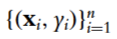 with each $x_i = (x_{i1}, ..., x_{id})^T$, we see an affine function to fit that data. The common approach invlves finding coefficients β_j's that minimize the criterion

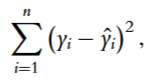

where

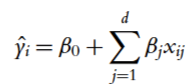

can be viewed as the predicted values of the linear model with coefficients β_j. The minimization problem can be formulated in matrix form. Let

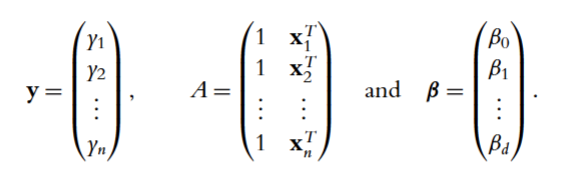

Then, the problem is transformed to

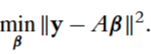

This is exactly the least-squares problem that we discuss in the last section

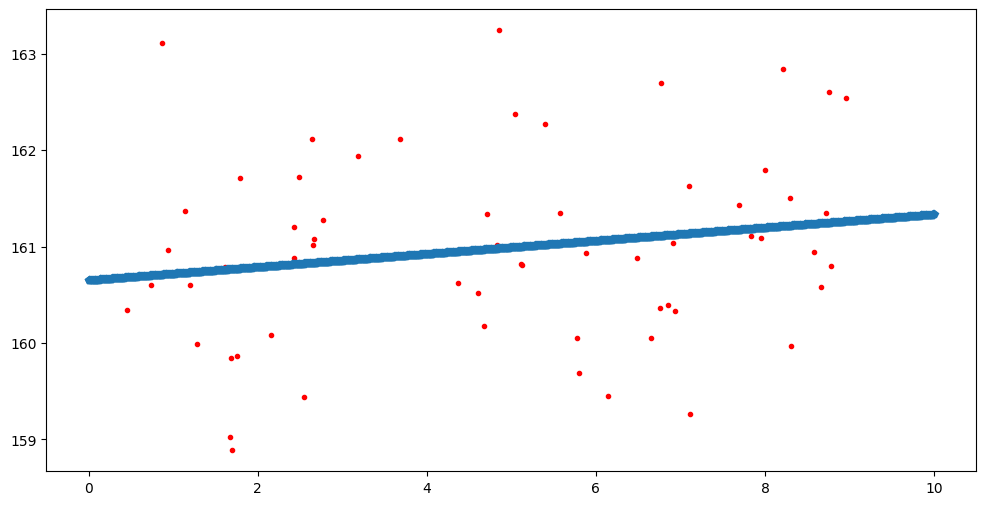

In [56]:
r = np.random.RandomState(26);
x = 9 * r.rand(62)
y = 23 * 7 + r.randn(62)

model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)
xfit = np.linspace(0, 10, 1000)
yfit = model.predict(xfit[:, np.newaxis])

plt.figure(figsize=(12,6))
plt.plot(x, y, 'r.')
plt.plot(xfit, yfit, 'p')

plt.show()